In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import os

In [3]:
os.environ["CUDA_VIBLE_DEVICES"] = "-1"
model_mbnv2 = tf.keras.models.load_model("steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch.keras")

2025-11-09 09:12:53.592230: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
def get_file_size(file_path):
    """Prints the size of a file in MB."""
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

In [7]:
print(f"Size of fine tuned model (MobileNetV2) = {get_file_size('steel_defect_clf_mobile_netv2_fine_tuning.keras')} MB")

Size of fine tuned model (MobileNetV2) = 23.315967559814453 MB


In [8]:
import pathlib

data_dir = pathlib.Path("/home/theorist/Desktop/Programming/ML/computing_tools/capstone-1/")
data_dir = data_dir / "train" / "images"
image_count = len(list(data_dir.glob('*/*.jpg')))

batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale'  
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=1,
  color_mode='grayscale' 
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1799 files belonging to 6 classes.
Using 1440 files for training.
Found 1799 files belonging to 6 classes.
Using 359 files for validation.
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


# 1. Baseline Keras model FP32

In [7]:
baseline_loss, baseline_acc = model_mbnv2.evaluate(val_ds)

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9944 - loss: 0.0115    


In [8]:
print(f"Baseline Keras Accuracy: {baseline_acc}")

Baseline Keras Accuracy: 0.9944289922714233


# 2. Post training quantization: weights(FP32 -> INT8)

In [10]:
from ai_edge_litert.interpreter import Interpreter

In [11]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dynamic_model = converter.convert()

tflite_dynamic_path = "mobilenetv2_dynamic_ptq.tflite"
with open(tflite_dynamic_path, 'wb') as f:
    f.write(tflite_dynamic_model)

INFO:tensorflow:Assets written to: /tmp/tmpctuyotva/assets


INFO:tensorflow:Assets written to: /tmp/tmpctuyotva/assets


Saved artifact at '/tmp/tmpctuyotva'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133213753143216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753328560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753336128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753394448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753342112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753342640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753393744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753400080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753397616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753399

W0000 00:00:1762618170.338955   20464 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762618170.338974   20464 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-11-08 21:39:30.339279: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpctuyotva
2025-11-08 21:39:30.346707: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-08 21:39:30.346721: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpctuyotva
I0000 00:00:1762618170.415419   20464 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-11-08 21:39:30.428952: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-08 21:39:30.954499: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpctuyotva
2025-11-08 21:39:31.076044: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [12]:
TFLITE_DYNAMIC_MODEL_PATH = "mobilenetv2_dynamic_ptq.tflite"
interpreter = Interpreter(model_path=TFLITE_DYNAMIC_MODEL_PATH)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:
def evaluate_tflite_model(interpreter, val_ds):
    """
    Evaluates the accuracy of a TFLite model on a validation dataset.

    Args:
        interpreter: The loaded and allocated TFLite interpreter.
        val_ds: The tf.data.Dataset to evaluate on.

    Returns:
        The validation accuracy as a float.
    """
    
    # 1. Get input and output tensor details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 2. Initialize lists to store all predictions and labels
    all_predictions = []
    all_labels = []

    print("Running evaluation...")
    
    # 3. Iterate through the validation dataset
    for images, labels in val_ds:
        # 4. Set the input tensor for each batch
        interpreter.set_tensor(input_details[0]['index'], images)
        
        # 5. Run inference
        interpreter.invoke()
        
        # 6. Get the output tensor (the model's predictions)
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        # Get the predicted class index by finding the max logit
        predicted_indices = np.argmax(output_data, axis=1)
        
        # 7. Store predictions and true labels
        all_predictions.extend(predicted_indices)
        all_labels.extend(labels.numpy())

    # 8. Calculate the final accuracy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    accuracy = np.sum(all_predictions == all_labels) / len(all_labels)
    
    return float(accuracy)

In [14]:
val_accuracy = evaluate_tflite_model(interpreter, val_ds)

Running evaluation...


2025-11-08 21:39:36.708874: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
val_accuracy

0.9860724233983287

In [16]:
get_file_size(tflite_dynamic_path)

2.3983688354492188

# 3. PQT FULL INT8

In [21]:
unbatched_train_ds = train_ds.unbatch()
representative_data = unbatched_train_ds.take(100)

def repr_data_gen():
  for image, _ in representative_data:
    yield [tf.expand_dims(image, 0)]

def evaluate_full_integer_model(tflite_path, val_ds):
    """
    Evaluates a full-integer TFLite model that requires int8 input.
    """
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Get quantization parameters for input/output
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    all_predictions = []
    all_labels = []

    print("Running evaluation on full integer model...")
    
    # Iterate through the validation dataset (which yields float32)
    for images, labels in val_ds:
        
        images_np = images.numpy()
        labels_np = labels.numpy()
        
        # Loop through each image in the batch
        # The new model expects batch_size=1 since our generator used it
        for i in range(images_np.shape[0]):
            image = images_np[i:i+1] # Get one image [1, 200, 200, 1]
            label = labels_np[i]
            
            # --- 1. Quantize the input image ---
            # (float32 / scale) + zero_point = int8
            image_quantized = (image / input_scale) + input_zero_point
            image_quantized = image_quantized.astype(input_details['dtype'])

            # Set the quantized image as input
            interpreter.set_tensor(input_details['index'], image_quantized)
            interpreter.invoke()
            
            # --- 2. Get the output and de-quantize it ---
            output_quantized = interpreter.get_tensor(output_details['index'])
            
            # (int8 - zero_point) * scale = float32
            output_float = (output_quantized.astype(np.float32) - output_zero_point) * output_scale

            # Get the final prediction
            predicted_label = np.argmax(output_float[0])
            
            all_predictions.append(predicted_label)
            all_labels.append(label)

    # Calculate final accuracy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    accuracy = np.sum(all_predictions == all_labels) / len(all_labels)
    return float(accuracy)

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = repr_data_gen

# Force full INT8 for MCU compatibility
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8  # For MCUs
converter.inference_output_type = tf.uint8 # For MCUs

tflite_int8_model = converter.convert()

# Save and check
tflite_int8_path = "mobilenetv2_int8_ptq.tflite"
with open(tflite_int8_path, 'wb') as f:
    f.write(tflite_int8_model)
print(f"Saved to {tflite_int8_path}")

INFO:tensorflow:Assets written to: /tmp/tmpqb2cma_o/assets


INFO:tensorflow:Assets written to: /tmp/tmpqb2cma_o/assets


Saved artifact at '/tmp/tmpqb2cma_o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133213753143216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753328560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753336128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753394448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753342112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753342640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753393744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753400080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753397616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133213753399

/home/theorist/Envs/ML-venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1762618248.174237   20464 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762618248.174255   20464 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-11-08 21:40:48.174406: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqb2cma_o
2025-11-08 21:40:48.182856: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-08 21:40:48.182877: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpqb2cma_o
2025-11-08 21:40:48.278936: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-08 21:40:48.857163: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp

Saved to mobilenetv2_int8_ptq.tflite


In [23]:
accuracy = evaluate_full_integer_model(tflite_int8_path, val_ds)
get_file_size(tflite_int8_path)

Running evaluation on full integer model...


2.592498779296875

In [24]:
accuracy

0.6740947075208914

## we need to patch our fine tuning since image net expects images in [-1, 1] range while ours are in [0, 255]

In [37]:
# Model 3: Fine tuning MobileNetV2

data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal_and_vertical", input_shape=(img_height, img_width, 1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ],
)

inputs = layers.Input(shape=(img_height, img_width, 1))

# 1. First, convert 1-channel grayscale to 3-channel "pseudo-RGB"
x = layers.Conv2D(3, (1, 1), padding='same')(inputs)

# 2. THEN, apply the rescaling expected by MobileNetV2
x = layers.Rescaling(1./127.5, offset=-1)(x)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False, # original clf is nto needed
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False
x = base_model(x, training=False)

# Add our custom clf head for thr 6 defects
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_3 = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_3.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model_3.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,676 (8.64 MB)

 Trainable params: 7,692 (30.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
# PHASE 1
initial_epochs = 10
print("--- Starting Phase 1: Feature Extraction ---")
history_phase1 = model_3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=initial_epochs
)

--- Starting Phase 1: Feature Extraction ---
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 908ms/step - accuracy: 0.5453 - loss: 1.2641 - val_accuracy: 0.9220 - val_loss: 0.4134
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 908ms/step - accuracy: 0.9315 - loss: 0.3493 - val_accuracy: 0.9471 - val_loss: 0.2478
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 907ms/step - accuracy: 0.9639 - loss: 0.1931 - val_accuracy: 0.9666 - val_loss: 0.1748
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 916ms/step - accuracy: 0.9717 - loss: 0.1533 - val_accuracy: 0.9638 - val_loss: 0.1396
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 913ms/step - accuracy: 0.9683 - loss: 0.1307 - val_accuracy: 0.9777 - val_loss: 0.1134
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 915ms/step - accuracy: 0.9799 - loss: 0.0997 - val_accuracy: 0.9833 - val_loss: 0.0965
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 913ms/step - accuracy: 0.9853 - loss: 0.0782 - val_accuracy: 0.9833 - val_loss: 0.0836
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 918ms/step

AttributeError: module 'tensorflow.keras' has no attribute 'opxtimizers'


--- Starting Phase 2: Fine-Tuning ---
Epoch 16/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 42s 889ms/step - accuracy: 0.9791 - loss: 0.0520 - val_accuracy: 0.9861 - val_loss: 0.0426
Epoch 17/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9919 - loss: 0.0224 - val_accuracy: 0.9944 - val_loss: 0.0216
Epoch 18/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 964ms/step - accuracy: 0.9907 - loss: 0.0204 - val_accuracy: 0.9889 - val_loss: 0.0386
Epoch 19/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 965ms/step - accuracy: 0.9911 - loss: 0.0223 - val_accuracy: 0.9777 - val_loss: 0.0691
Epoch 20/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 966ms/step - accuracy: 0.9950 - loss: 0.0150 - val_accuracy: 0.9805 - val_loss: 0.0460
Epoch 21/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 970ms/step - accuracy: 0.9927 - loss: 0.0139 - val_accuracy: 0.9861 - val_loss: 0.0316
Epoch 22/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 971ms/step - accuracy: 0.9986 - loss: 0.0073 - val_accuracy: 0.9805 - val_loss: 0.0394
Epoch 23/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 975ms/step 

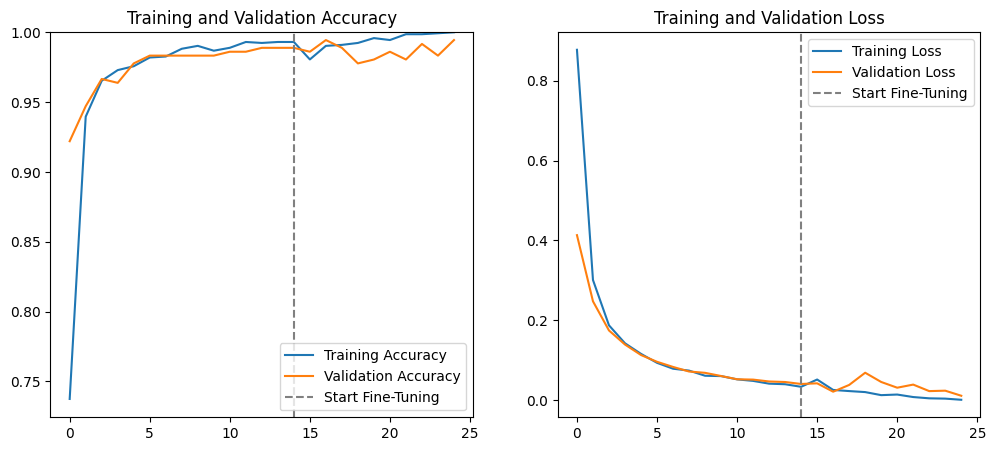

In [39]:
# PHASE 2

base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_fine_tune = tf.keras.optimizers.Adam(learning_rate=1e-5)
model_3.compile(
    optimizer=optimizer_fine_tune,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print("\n--- Starting Phase 2: Fine-Tuning ---")

fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_phase2 = model_3.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    validation_data=val_ds,
)

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([min(plt.ylim()), 1])
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [40]:
model_3.save('steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch.keras')

In [9]:
predictions = model_mbnv2.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


2025-11-09 09:14:19.016351: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        52
      inclusion       1.00      0.97      0.99        75
        patches       1.00      1.00      1.00        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       1.00      1.00      1.00        61
      scratches       0.97      1.00      0.98        56

       accuracy                           0.99       359
      macro avg       0.99      1.00      0.99       359
   weighted avg       0.99      0.99      0.99       359



In [11]:
confidences = np.max(predictions, axis=1)
for i in range(100):
    print(f"Sample {i}:")
    print(f"  Predicted class: {y_pred[i]}")
    print(f"  Confidence: {confidences[i]:.2%}")

Sample 0:
  Predicted class: 4
  Confidence: 100.00%
Sample 1:
  Predicted class: 1
  Confidence: 99.98%
Sample 2:
  Predicted class: 5
  Confidence: 100.00%
Sample 3:
  Predicted class: 0
  Confidence: 100.00%
Sample 4:
  Predicted class: 3
  Confidence: 100.00%
Sample 5:
  Predicted class: 1
  Confidence: 99.99%
Sample 6:
  Predicted class: 4
  Confidence: 100.00%
Sample 7:
  Predicted class: 1
  Confidence: 99.50%
Sample 8:
  Predicted class: 5
  Confidence: 100.00%
Sample 9:
  Predicted class: 4
  Confidence: 100.00%
Sample 10:
  Predicted class: 5
  Confidence: 99.97%
Sample 11:
  Predicted class: 5
  Confidence: 100.00%
Sample 12:
  Predicted class: 5
  Confidence: 100.00%
Sample 13:
  Predicted class: 1
  Confidence: 99.99%
Sample 14:
  Predicted class: 2
  Confidence: 100.00%
Sample 15:
  Predicted class: 3
  Confidence: 99.99%
Sample 16:
  Predicted class: 3
  Confidence: 99.98%
Sample 17:
  Predicted class: 0
  Confidence: 99.99%
Sample 18:
  Predicted class: 0
  Confidence: 

# 3. quantization aware training

In [7]:
import tensorflow_model_optimization as tfmot

In [15]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

num_images = len(train_ds)
end_step = np.ceil(num_images / batch_size).astype(np.int32) * 2

# 50% pruning
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50, final_sparsity=0.80, begin_step=0, end_step=end_step)
}